In [11]:
import pandas as pd
import numpy as np
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk as nltk

In [2]:

TREC_Data_PATH = "../CORPORA/TREC/TREC_documents.tsv"

# RELISH data analysis

In [3]:
RESLISH_Data_PATH = "../CORPORA/RELISH/RELISH_documents.tsv"

relish_data = pd.read_csv(RESLISH_Data_PATH, sep='\t')
relish_data.head()

,PMID,title,abstract
0,26747586,A Multiplexed Amplicon Approach for Detecting ...,Chromosomal rearrangements that result in onco...
1,26784937,NTRK fusion oncogenes in pediatric papillary t...,"BACKGROUND: An increase in thyroid cancers, pr..."
2,26973202,"ALK, ROS1 and RET rearrangements in lung squam...",OBJECTIVES: Chromosomal rearrangements of ALK ...
3,27259011,Recurrent NTRK1 Gene Fusions Define a Novel Su...,The family of pediatric fibroblastic and myofi...
4,27343444,Custom Gene Capture and Next-Generation Sequen...,INTRODUCTION: We performed a genomic study in ...


In [4]:
print("Given dataset shape is: {}".format(relish_data.shape))
print("Given dataset columns are: {}".format(relish_data.columns))
print("Total number of PMIDs in RELISH:",relish_data["PMID"].value_counts().shape[0])
print("Total number of unique PMIDs in RELISH:",relish_data["PMID"].nunique())
print("Total number of empty PMIDs in RELISH:",relish_data["PMID"].isnull().sum())
print("Range of PMIDs in RELISH:",relish_data["PMID"].min(),relish_data["PMID"].max())

Given dataset shape is: (163190, 3)
Given dataset columns are: Index(['PMID', 'title', 'abstract'], dtype='object')
Total number of PMIDs in RELISH: 163190
Total number of unique PMIDs in RELISH: 163190
Total number of empty PMIDs in RELISH: 0
Range of PMIDs in RELISH: 1424236 29990624


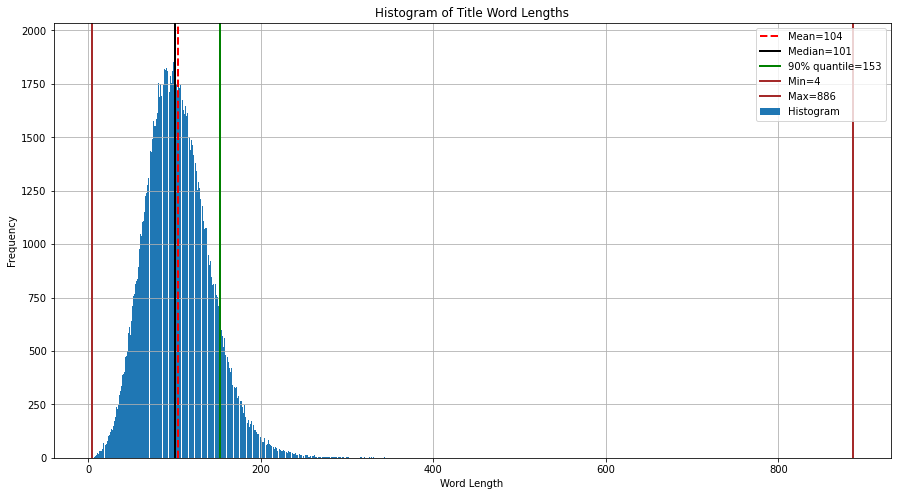

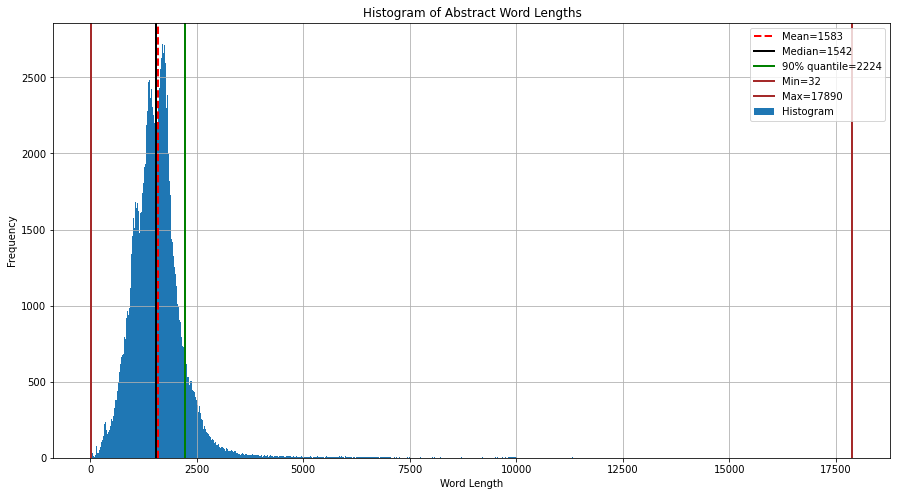

In [7]:
title_word_lens = relish_data["title"].str.len()
mean=round(np.mean(title_word_lens))
median = round(np.median(title_word_lens))
quantile = round(np.quantile(title_word_lens,0.90))
min_ = round(np.min(title_word_lens))
max_ = round(np.max(title_word_lens))
plt.figure(figsize=(15,8))
plt.hist(title_word_lens, bins=1000)
plt.axvline(x=mean, color='r', linestyle='dashed', linewidth=2)
plt.axvline(x=median, color='black', linewidth=2)
plt.axvline(x=quantile, color='g', linewidth=2)
plt.axvline(x=max_, color='brown', linewidth=2)
plt.axvline(x=min_, color='brown', linewidth=2)
plt.title("Histogram of Title Word Lengths")
plt.xlabel("Word Length")
plt.ylabel("Frequency")
plt.legend(['Mean='+str(mean),'Median='+str(median),'90% quantile='+str(quantile),
            'Min='+str(min_),'Max='+str(max_),'Histogram'], loc='upper right')
plt.grid()
plt.show()

abstract_word_lens = relish_data["abstract"].str.len()
mean = round(np.mean(abstract_word_lens))
median = round(np.median(abstract_word_lens))
quantile = round(np.quantile(abstract_word_lens,0.90))
min_ = round(np.min(abstract_word_lens))
max_ = round(np.max(abstract_word_lens))
plt.figure(figsize=(15,8))
plt.hist(abstract_word_lens, bins=1000)
plt.axvline(x=mean, color='r', linestyle='dashed', linewidth=2)
plt.axvline(x=median, color='black', linewidth=2)
plt.axvline(x=quantile, color='g', linewidth=2)
plt.axvline(x=min_, color='brown', linewidth=2)
plt.axvline(x=max_, color='brown', linewidth=2)
plt.title("Histogram of Abstract Word Lengths")
plt.xlabel("Word Length")
plt.ylabel("Frequency")
plt.legend(['Mean='+str(mean),'Median='+str(median),'90% quantile='+str(quantile),
            'Min='+str(min_),'Max='+str(max_),'Histogram'], loc='upper right')
plt.grid()
plt.show()

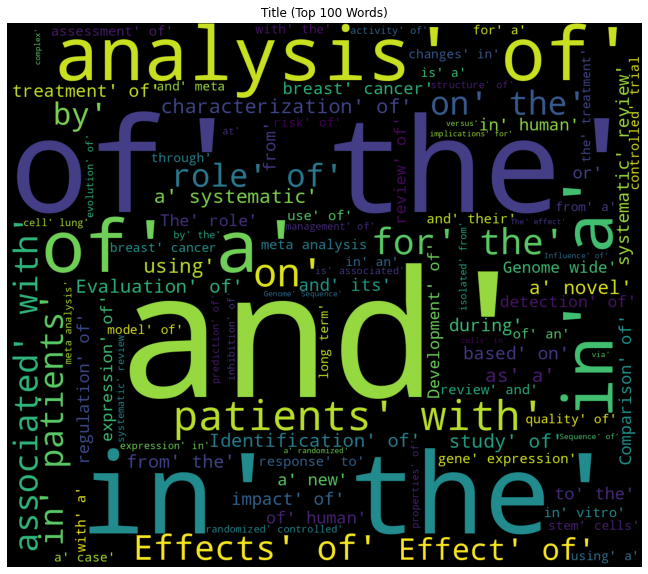

In [8]:
# list of unique words in titles
title_words = relish_data["title"].str.split(" ").apply(pd.Series, "keyword").stack().tolist()

def generate_wordcloud(data,title=""):
    plt.subplots(figsize=(16,10))
    wordcloud = WordCloud(
                            background_color='black',
                            max_words=100,
                            width=1400,
                            height=1200
                            ).generate(str(title_words))
    plt.imshow(wordcloud)
    plt.title(title+" "+'(Top 100 Words)')
    plt.axis('off')
    plt.show()

generate_wordcloud(title_words,title="Title")